In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
# Load data
df = pd.read_csv('Data/Clean/Final-v4.csv')

In [3]:
EU27 = [
    "AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
]
OUTSIDE   = ["GBR","CHE","NOR"]
# OUTSIDE   += ["USA"]
COUNTRIES = EU27 + OUTSIDE          # n = 31

# df = df[df["iso3_i"].isin(COUNTRIES) & df["iso3_j"].isin(COUNTRIES)].copy()

In [4]:
df.columns

Index(['iso3_i', 'iso3_j', 'year', 'total_pip_million_usd_i',
       'total_pip_million_usd_j', 'a_ij', 'r_i', 'r_j', 'Y_i', 'k_i', 'L_i',
       'pop_i', 'lab_sh_i', 'delta_i', 'A_i', 'rf_i', 'inv_share_i', 'hc_i',
       'alpha_i', 'Y_j', 'k_j', 'L_j', 'pop_j', 'lab_sh_j', 'delta_j', 'A_j',
       'rf_j', 'inv_share_j', 'hc_j', 'alpha_j', 'euro_i', 'euro_j',
       'total_portfolio_million_usd_i', 'total_portfolio_million_usd_j',
       'bis_debt_i', 'gci_corruption_i', 'gci_financial_composite_i',
       'gci_financial_depth_i', 'gci_financial_stability_i', 'gci_overall_i',
       'gci_trade_openness_i', 'gci_corruption_j', 'gci_financial_composite_j',
       'gci_financial_depth_j', 'gci_financial_stability_j', 'gci_overall_j',
       'gci_trade_openness_j', 'ka_open_i', 'ka_open_j',
       'financial_development_index_i', 'financial_development_index_j',
       'NumEvents', 'NumArticles', 'Sum_NumArticles', 'Sum_NumEvents',
       'Intensity_Articles', 'Log_NumArticles', 'Log_NumE

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].corrwith(df["a_ij"]).sort_values(ascending=False, key=abs).head(10)

a_ij                             1.000000
NumEvents                        0.457783
d_numevents                     -0.457783
total_pip_million_usd_j          0.427103
total_portfolio_million_usd_j    0.379004
total_pip_million_usd_i          0.368040
k_j                              0.338986
Log_NumEvents                    0.332140
total_portfolio_million_usd_i    0.330907
language_proximity               0.330720
dtype: float64

In [6]:
df[num_cols].isna().mean().sort_values(ascending=False).head(20)

a_ij                             0.987432
d_cul                            0.982658
total_portfolio_million_usd_j    0.956790
total_portfolio_million_usd_i    0.956790
Log_NumArticles                  0.953836
d_num_articles                   0.953836
NumArticles                      0.953836
Intensity_Articles               0.953836
Sum_NumArticles                  0.953836
Sum_NumEvents                    0.953836
Log_NumEvents                    0.953836
d_news                           0.953836
d_numevents                      0.953836
NumEvents                        0.953836
gci_financial_stability_j        0.934789
gci_financial_depth_j            0.934789
gci_financial_composite_i        0.934789
gci_trade_openness_i             0.934789
gci_financial_stability_i        0.934789
gci_overall_j                    0.934789
dtype: float64

In [7]:
# df["d_ling"] = 1 - df["lang_share"]
# df["ln_d_geo"] = np.log(df["d_geo"])
# df["ln_a_ij"] = np.log1p(df["a_ij"])
# df["euro_ij"] = df["euro_i"] * df["euro_j"]

# # Replace inf with nan in ln_d_geo
# df = df.replace([np.inf, -np.inf], np.nan)

In [8]:
# # Standardise each component to [0, 1] range
# geo_norm = (df['ln_d_geo'] - df['ln_d_geo'].min()) / (df['ln_d_geo'].max() - df['ln_d_geo'].min())
# ling_norm = df['d_ling']  # already 0-1
# cul_norm = df['d_cul'] / df['d_cul'].max()  # scale to 0-1

# # Composite: average of available components
# df['d_composite'] = pd.concat([geo_norm, ling_norm, cul_norm], axis=1).mean(axis=1, skipna=True)

In [9]:
df["d_gci_overall"] = np.abs(df["gci_overall_i"] - df["gci_overall_j"])
df["d_gci_corruption"] = np.abs(df["gci_corruption_i"] - df["gci_corruption_j"])
df["d_gci_trade_openness"] = np.abs(df["gci_trade_openness_i"] - df["gci_trade_openness_j"])
df["d_gci_financial_composite"] = np.abs(df["gci_financial_composite_i"] - df["gci_financial_composite_j"])
df["d_gci_financial_depth"] = np.abs(df["gci_financial_depth_i"] - df["gci_financial_depth_j"])
df["d_gci_financial_stability"] = np.abs(df["gci_financial_stability_i"] - df["gci_financial_stability_j"])
df["d_ka_open"] = np.abs(df["ka_open_i"] - df["ka_open_j"])
df["euro_ij"] = df["euro_i"] * df["euro_j"]
df["eu_ij"] = ((df["iso3_i"].isin(EU27)) & (df["iso3_j"].isin(EU27))).astype(int)
df["d_legal_origin"] = (df["legal_origin_i"] != df["legal_origin_j"]).astype(int)
df["d_financial_development_index"] = np.abs(df["financial_development_index_i"] - df["financial_development_index_j"])

# Construct undirected bilateral pair id first
df["pair"] = df.apply(lambda r: "_".join(sorted([r["iso3_i"], r["iso3_j"]])), axis=1)

ppml_df = df[df["iso3_i"] != df["iso3_j"]].copy()
ppml_df = ppml_df[ppml_df["iso3_i"].isin(COUNTRIES) & ppml_df["iso3_j"].isin(COUNTRIES)].copy()

# Construct the pairs
ppml_df["pair"] = ppml_df.apply(lambda row: '_'.join(sorted([row['iso3_i'], row['iso3_j']])), axis=1)

cols = ["a_ij", "d_ling", "d_financial_development_index", "d_num_articles", "d_geo", "year", "iso3_i", "iso3_j", "Y_i", "Y_j"]


# Drop rows with missing covariates; keep zero a_ij (PPML handles zeros correctly)
ppml_df = ppml_df.dropna(subset=cols).copy()
# Fill nan with zeros for covariates (if any remain); PPML can handle zeros but not nans
# ppml_df[cols] = ppml_df[cols].fillna(0)

# Change Y to /1e3 and round to reduce massive numbers in interaction term
ppml_df["Y_i"] = ppml_df["Y_i"].div(1e6).round(3)
ppml_df["Y_j"] = ppml_df["Y_j"].div(1e6).round(3)
ppml_df["a_ij"] = ppml_df["a_ij"].div(1e6).round(3)

# PPML requires non-negative (not strictly positive) a_ij — zero flows are valid
ppml_df["a_ij"] = ppml_df["a_ij"].clip(lower=0)

num_cols = ppml_df[cols].select_dtypes(include=[np.number]).columns

n_zeros = (ppml_df["a_ij"] == 0).sum()
n_pos   = (ppml_df["a_ij"]  > 0).sum()
print(f"Sample: {len(ppml_df):,} obs  |  positive: {n_pos:,}  |  zeros: {n_zeros:,}")

formula = 'a_ij ~ d_ling + d_num_articles + d_financial_development_index + d_geo + Y_i + Y_j + C(year)'
model = smf.poisson(
    formula=formula,
    data=ppml_df,
).fit(
    method="newton",      # Use Newton-Raphson instead of BFGS
    maxiter=300,
    cov_type="cluster",
    cov_kwds={"groups": ppml_df['pair']},
)

print(model.summary())


Sample: 2,858 obs  |  positive: 1,691  |  zeros: 1,167
Optimization terminated successfully.
         Current function value: 0.069133
         Iterations 9
                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                 2858
Model:                        Poisson   Df Residuals:                     2846
Method:                           MLE   Df Model:                           11
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.2488
Time:                        16:34:12   Log-Likelihood:                -197.58
converged:                       True   LL-Null:                       -263.01
Covariance Type:              cluster   LLR p-value:                 1.163e-22
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept      

In [10]:
ppml_df[["d_ling", "d_num_articles", "d_financial_development_index", "d_geo", "Y_i", "Y_j"]].describe()

,d_ling,d_num_articles,d_financial_development_index,d_geo,Y_i,Y_j
count,2858.000000,2858.000000,2858.000000,2858.000000,2858.000000,2858.000000
mean,0.614230,0.996277,0.245209,1401.965031,1.165378,1.183324
std,0.227147,0.012266,0.172528,737.614728,1.372324,1.368946
min,0.006539,0.795394,0.001000,127.004291,0.017000,0.017000
25%,0.517260,0.997823,0.101000,821.245494,0.284000,0.292000
50%,0.678716,0.999292,0.213000,1303.365994,0.516000,0.527000
75%,0.776417,0.999764,0.368000,1851.062053,1.879000,1.909000
max,0.926690,1.000000,0.768000,3768.120503,5.072000,5.072000


In [11]:
# Save gravity model predictions alongside actuals
pred_df = ppml_df[["iso3_i", "iso3_j", "year", "a_ij"]].copy()
pred_df["a_ij_pred"] = model.predict(ppml_df)

pred_df.to_csv("v4-gravity_pred.csv", index=False)
print(f"Saved {len(pred_df):,} rows to v4-gravity_pred.csv")
print(pred_df.head())

Saved 2,858 rows to v4-gravity_pred.csv
      iso3_i iso3_j  year   a_ij  a_ij_pred
82695    AUT    BGR  2015  0.000   0.002891
82696    AUT    BGR  2016  0.000   0.002460
82697    AUT    BGR  2017  0.001   0.002923
82698    AUT    BGR  2018  0.000   0.002445
82699    AUT    BGR  2019  0.000   0.002964


In [12]:
# plot the d_ling, numarticles, d_gci_financial_composite coefficients scatter matrix
from pandas.plotting import scatter_matrix

scat_df = df[["d_ling", "d_geo", "d_financial_development_index", "d_num_articles", "a_ij"]]
# scatter_matrix(scat_df, alpha=0.2, figsize=(10, 10), diagonal='kde')
# plt.suptitle("Scatter Matrix of Key Variables")
# plt.show()

scat_df.isna().mean()

d_ling                           0.361801
d_geo                            0.064658
d_financial_development_index    0.728061
d_num_articles                   0.953836
a_ij                             0.987432
dtype: float64

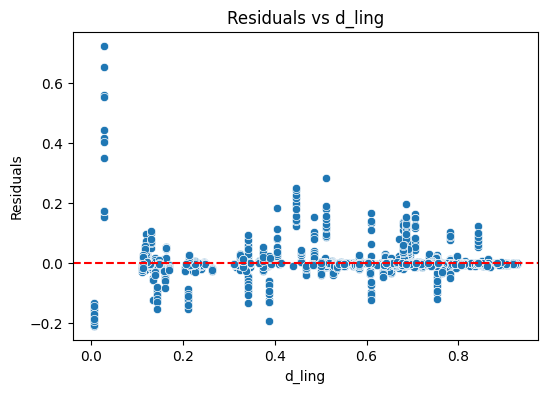

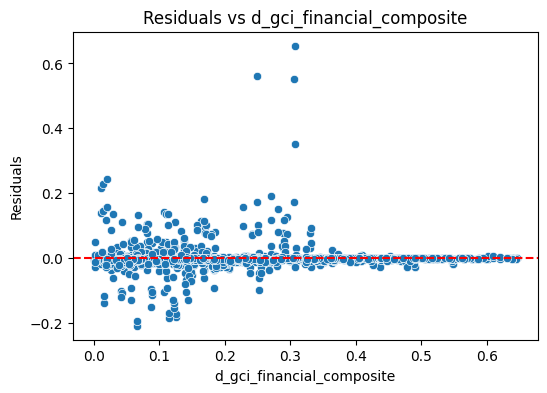

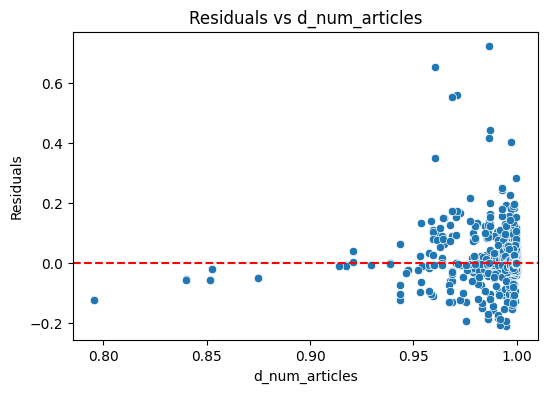

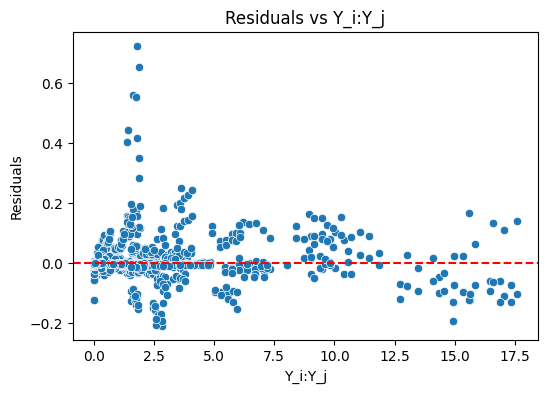

In [13]:
# plot scatter plots of residual against all of the variables in the model
residuals = model.resid_response
ppml_df["Y_i:Y_j"] = ppml_df["Y_i"] * ppml_df["Y_j"]

for col in ["d_ling", "d_gci_financial_composite", "d_num_articles", "Y_i:Y_j"]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=ppml_df[col], y=residuals)
    plt.title(f"Residuals vs {col}")
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

In [14]:
# Endogeneity Test for d_num_articles: First-Stage Strength Check
# If d_num_articles is not explained by exogenous variables, it could be endogenous
print("=" * 70)
print("ENDOGENEITY TEST FOR d_num_articles")
print("=" * 70)

# Step 1: First-stage regression
# Predict d_num_articles from exogenous variables
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

exog_vars = ["d_ling", "d_financial_development_index", "d_geo"]
X_exog = ppml_df[exog_vars].values
y_d_num = ppml_df["d_num_articles"].values

first_stage = LinearRegression().fit(X_exog, y_d_num)
d_num_pred = first_stage.predict(X_exog)
r2_first = r2_score(y_d_num, d_num_pred)

# Get residual standard deviation
d_num_resid = y_d_num - d_num_pred
resid_std = np.std(d_num_resid)

print("\nFIRST-STAGE REGRESSION RESULTS:")
print(f"  Dependent variable: d_num_articles")
print(f"  Predictors: d_ling, d_financial_development_index, d_geo")
print(f"\n  R-squared: {r2_first:.6f}")
print(f"  Variation explained by exogenous variables: {r2_first*100:.2f}%")
print(f"  Residual std dev: {resid_std:.8f}")
print(f"  d_num_articles std dev: {np.std(y_d_num):.8f}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)

if r2_first > 0.90:
    print("✓ d_num_articles is WELL-EXPLAINED by exogenous variables")
    print("  → Suggests d_num_articles is EXOGENOUS (not endogenous)")
    print("  → Safe to use in model")
elif r2_first > 0.70:
    print("⚠ d_num_articles is PARTIALLY explained by exogenous variables")
    print("  → Mixed evidence; some endogeneity concerns possible")
else:
    print("✗ d_num_articles is POORLY explained by exogenous variables")
    print("  → Suggests d_num_articles may be ENDOGENOUS")
    print("  → Consider IV estimation or exclude from model")

print("\nNOTE: d_num_articles has very low variation (std={:.6f})".format(np.std(y_d_num)))
print("This suggests it adds minimal information regardless of endogeneity.")
print("=" * 70)

ENDOGENEITY TEST FOR d_num_articles

FIRST-STAGE REGRESSION RESULTS:
  Dependent variable: d_num_articles
  Predictors: d_ling, d_financial_development_index, d_geo

  R-squared: 0.034120
  Variation explained by exogenous variables: 3.41%
  Residual std dev: 0.01205264
  d_num_articles std dev: 0.01226368

INTERPRETATION:
✗ d_num_articles is POORLY explained by exogenous variables
  → Suggests d_num_articles may be ENDOGENOUS
  → Consider IV estimation or exclude from model

NOTE: d_num_articles has very low variation (std=0.012264)
This suggests it adds minimal information regardless of endogeneity.
